In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import linear_model
%matplotlib inline

In [2]:
df=pd.read_csv('car_showroom_data.csv')
df.head()

,Model Number,Name,Model,Color,Manufacturing Company,Additional Features,Mileage,Engine CC,Price,Reviews
0,SLMVYWJ5,Maxima,2016,Silver,Rolls-Royce,Blind Spot Monitoring; Premium Sound System; L...,21.6,2957.1,54960.26,4.8
1,3D72PVY4,F-250,2022,Silver,Suzuki,Sunroof; Bluetooth; Adaptive Cruise Control; N...,22.1,4233.7,50094.42,4.3
2,URRAVSAL,CX-5,2016,Black,Chevrolet,Lane Departure Warning; Adaptive Cruise Contro...,21.1,1172.5,21500.81,4.0
3,RBHHWE32,Altima,2011,Yellow,Rolls-Royce,Backup Camera; Premium Sound System; Blind Spo...,27.2,4210.9,27198.50,3.2
4,EF7C0AAN,X3,2022,Yellow,Mitsubishi,Premium Sound System,25.0,4497.4,77489.91,4.8


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Model Number           1000 non-null   object 
 1   Name                   1000 non-null   object 
 2   Model                  1000 non-null   int64  
 3   Color                  1000 non-null   object 
 4   Manufacturing Company  1000 non-null   object 
 5   Additional Features    1000 non-null   object 
 6   Mileage                1000 non-null   float64
 7   Engine CC              1000 non-null   float64
 8   Price                  1000 non-null   float64
 9   Reviews                1000 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 78.3+ KB


In [4]:
df.isnull().sum()

Model Number             0
Name                     0
Model                    0
Color                    0
Manufacturing Company    0
Additional Features      0
Mileage                  0
Engine CC                0
Price                    0
Reviews                  0
dtype: int64

<Axes: title={'center': 'Average car showroom'}, xlabel='Model'>

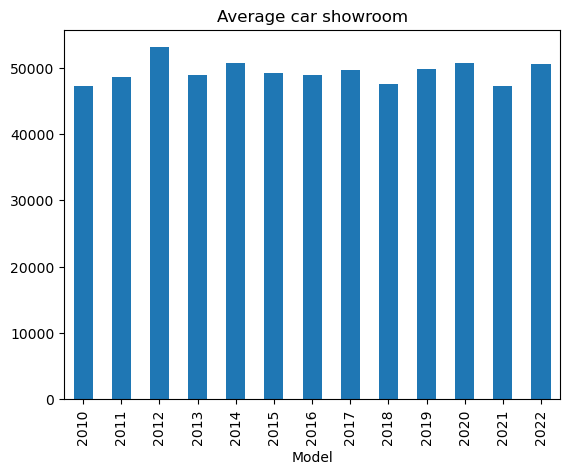

In [5]:
df.groupby('Model')['Price'].mean().plot(kind='bar',title='Average car showroom')

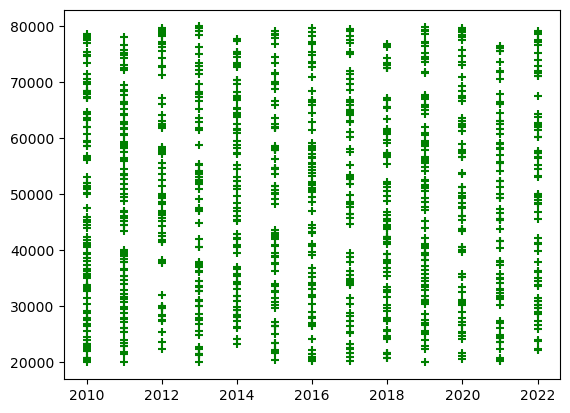

In [6]:
plt.scatter(df['Model'],df['Price'],color='green',marker='+')

In [7]:
df.head()

,Model Number,Name,Model,Color,Manufacturing Company,Additional Features,Mileage,Engine CC,Price,Reviews
0,SLMVYWJ5,Maxima,2016,Silver,Rolls-Royce,Blind Spot Monitoring; Premium Sound System; L...,21.6,2957.1,54960.26,4.8
1,3D72PVY4,F-250,2022,Silver,Suzuki,Sunroof; Bluetooth; Adaptive Cruise Control; N...,22.1,4233.7,50094.42,4.3
2,URRAVSAL,CX-5,2016,Black,Chevrolet,Lane Departure Warning; Adaptive Cruise Contro...,21.1,1172.5,21500.81,4.0
3,RBHHWE32,Altima,2011,Yellow,Rolls-Royce,Backup Camera; Premium Sound System; Blind Spo...,27.2,4210.9,27198.50,3.2
4,EF7C0AAN,X3,2022,Yellow,Mitsubishi,Premium Sound System,25.0,4497.4,77489.91,4.8


In [8]:
df1=df.drop(['Model Number','Name','Color','Additional Features','Reviews'],axis='columns')

In [9]:
df1

,Model,Manufacturing Company,Mileage,Engine CC,Price
0,2016,Rolls-Royce,21.6,2957.1,54960.26
1,2022,Suzuki,22.1,4233.7,50094.42
2,2016,Chevrolet,21.1,1172.5,21500.81
3,2011,Rolls-Royce,27.2,4210.9,27198.50
4,2022,Mitsubishi,25.0,4497.4,77489.91
...,...,...,...,...,...
995,2018,Suzuki,25.4,1829.9,31755.17
996,2015,Rolls-Royce,19.8,4998.7,30858.00
997,2013,Mitsubishi,11.6,2333.8,79789.85
998,2019,Mitsubishi,16.4,4814.2,56703.76


In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [12]:
df1['Company']=le.fit_transform(df1['Manufacturing Company'])

In [13]:
df1

,Model,Manufacturing Company,Mileage,Engine CC,Price,Company
0,2016,Rolls-Royce,21.6,2957.1,54960.26,4
1,2022,Suzuki,22.1,4233.7,50094.42,5
2,2016,Chevrolet,21.1,1172.5,21500.81,2
3,2011,Rolls-Royce,27.2,4210.9,27198.50,4
4,2022,Mitsubishi,25.0,4497.4,77489.91,3
...,...,...,...,...,...,...
995,2018,Suzuki,25.4,1829.9,31755.17,5
996,2015,Rolls-Royce,19.8,4998.7,30858.00,4
997,2013,Mitsubishi,11.6,2333.8,79789.85,3
998,2019,Mitsubishi,16.4,4814.2,56703.76,3


In [14]:
df2=df1.drop(['Manufacturing Company'],axis='columns')

In [15]:
df2

,Model,Mileage,Engine CC,Price,Company
0,2016,21.6,2957.1,54960.26,4
1,2022,22.1,4233.7,50094.42,5
2,2016,21.1,1172.5,21500.81,2
3,2011,27.2,4210.9,27198.50,4
4,2022,25.0,4497.4,77489.91,3
...,...,...,...,...,...
995,2018,25.4,1829.9,31755.17,5
996,2015,19.8,4998.7,30858.00,4
997,2013,11.6,2333.8,79789.85,3
998,2019,16.4,4814.2,56703.76,3


In [16]:
x=df2.drop(['Price'],axis='columns')
y=df2['Price']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8)

In [17]:
x_test

,Model,Mileage,Engine CC,Company
86,2018,10.3,2003.4,3
212,2018,26.8,2023.3,5
293,2011,10.3,2822.9,4
749,2011,27.2,3691.5,2
732,2014,23.4,2554.9,4
...,...,...,...,...
323,2011,11.5,2305.0,5
155,2013,14.3,1106.0,0
764,2022,26.7,3741.5,4
332,2011,20.9,3690.6,5


In [18]:
model.fit(x_train,y_train)

LinearRegression()

In [19]:
x_test

,Model,Mileage,Engine CC,Company
86,2018,10.3,2003.4,3
212,2018,26.8,2023.3,5
293,2011,10.3,2822.9,4
749,2011,27.2,3691.5,2
732,2014,23.4,2554.9,4
...,...,...,...,...
323,2011,11.5,2305.0,5
155,2013,14.3,1106.0,0
764,2022,26.7,3741.5,4
332,2011,20.9,3690.6,5


In [20]:
model.predict([[2014,23,2000,5]])

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([48302.28565417])

In [21]:
model.score(x_test,y_test)

-0.0031029570877754153

In [23]:
model.score(x_train,y_train)

0.003066134267174503